# Análise e Simulação de um Circuito RLC em Série

Modelagem matemática e simulação computacional de um circuito RLC de segunda ordem.

## 1. Descrição Física e Equações Diferenciais

Considere um circuito em série composto por uma fonte de tensão de entrada $V_{in}(t)$, um resistor $R$, um indutor $L$ e um capacitor $C$. O objetivo é analisar a tensão de saída sobre o capacitor, $V_c(t)$.

Pela Lei das Malhas de Kirchhoff (LKT):

$$V_{in}(t) = V_R(t) + V_L(t) + V_c(t)$$

Substituindo as relações de tensão e corrente:
- **Resistor:** $V_R(t) = R \cdot i(t)$
- **Indutor:** $V_L(t) = L \cdot \frac{di(t)}{dt}$
- **Capacitor:** $i(t) = C \cdot \frac{dV_c(t)}{dt}$

A equação diferencial que governa o sistema é:

$$LC \frac{d^2V_c(t)}{dt^2} + RC \frac{dV_c(t)}{dt} + V_c(t) = V_{in}(t)$$

## 2. Função de Transferência

Aplicando a Transformada de Laplace com condições iniciais nulas:

$$H(s) = \frac{V_c(s)}{V_{in}(s)} = \frac{\frac{1}{LC}}{s^2 + \frac{R}{L}s + \frac{1}{LC}}$$

Relacionando com a forma padrão $s^2 + 2\zeta\omega_n s + \omega_n^2 = 0$:
- **Frequência natural ($\omega_n$):** $\omega_n = \frac{1}{\sqrt{LC}}$
- **Fator de amortecimento ($\zeta$):** $\zeta = \frac{R}{2} \sqrt{rac{C}{L}}$

## 3. Simulação Computacional

Utilizaremos as bibliotecas `scipy.signal` para a análise do sistema e `matplotlib` para visualização.

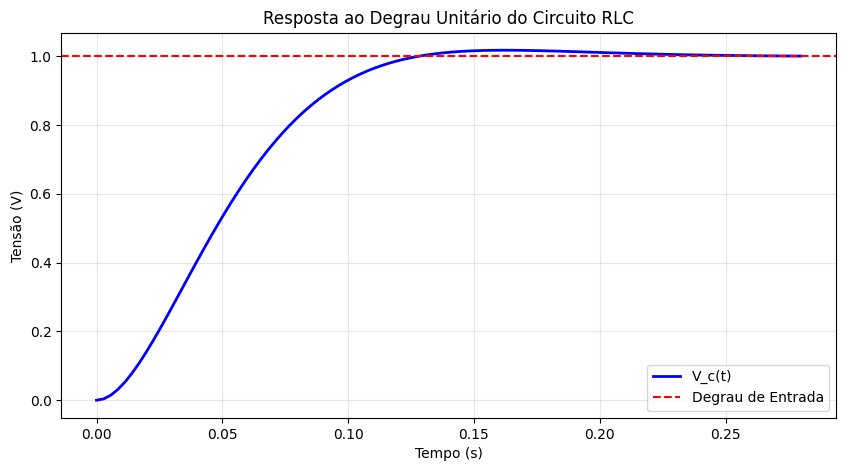

Polos do sistema: [-25.+19.36491673j -25.-19.36491673j]


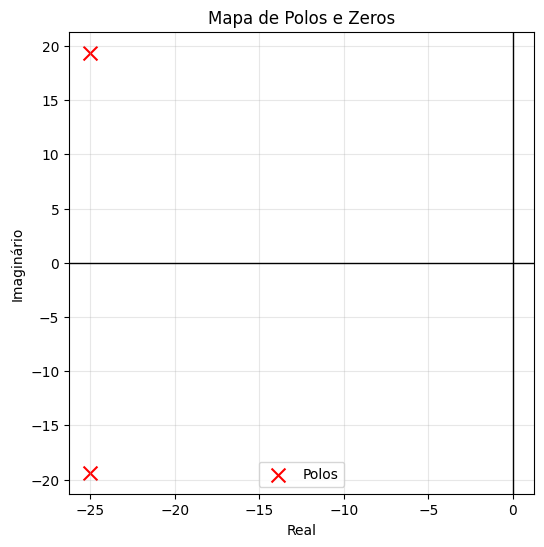

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Definição dos parâmetros do circuito
R = 50    # Ohms
L = 1     # Henry
C = 0.001 # Farads

# Construção da Função de Transferência H(s) = num / den
num = [1 / (L * C)]
den = [1, R / L, 1 / (L * C)]
sys = signal.TransferFunction(num, den)

# Resposta ao degrau
t, y = signal.step(sys)

# Gráfico da resposta temporal
plt.figure(figsize=(10, 5))
plt.plot(t, y, label='V_c(t)', color='blue', linewidth=2)
plt.axhline(1, color='red', linestyle='--', label='Degrau de Entrada')
plt.title('Resposta ao Degrau Unitário do Circuito RLC')
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Localização dos Polos
poles = sys.poles
print(f"Polos do sistema: {poles}")

# Gráfico do Mapa de Polos e Zeros
plt.figure(figsize=(6, 6))
plt.scatter(np.real(poles), np.imag(poles), marker='x', color='red', s=100, label='Polos')
plt.axvline(0, color='black', linewidth=1)
plt.axhline(0, color='black', linewidth=1)
plt.title('Mapa de Polos e Zeros')
plt.xlabel('Real')
plt.ylabel('Imaginário')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4. Discussão dos Resultados

A dinâmica do sistema depende da posição dos polos:
- **Subamortecido ($0 < \zeta < 1$):** Polos complexos conjugados. Resposta oscilatória.
- **Criticamente Amortecido ($\zeta = 1$):** Polos reais idênticos. Resposta mais rápida sem oscilação.
- **Superamortecido ($\zeta > 1$):** Polos reais distintos. Resposta lenta e sem oscilação.

## 5. Aplicações Reais

- **Filtros de Sinais:** Utilizados em receptores de rádio para selecionar frequências específicas.
- **Eletrônica de Potência:** Circuitos de proteção (snubbers) para evitar picos de tensão.
- **Sistemas de Comunicação:** Equalização de linhas de transmissão.